In [1]:

# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES
# TO THE CORRECT LOCATION (/kaggle/input) IN YOUR NOTEBOOK,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

import os
import sys
from tempfile import NamedTemporaryFile
from urllib.request import urlopen
from urllib.parse import unquote, urlparse
from urllib.error import HTTPError
from zipfile import ZipFile
import tarfile
import shutil

CHUNK_SIZE = 40960
DATA_SOURCE_MAPPING = 'brain-mri-images-for-brain-tumor-detection:https%3A%2F%2Fstorage.googleapis.com%2Fkaggle-data-sets%2F165566%2F377107%2Fbundle%2Farchive.zip%3FX-Goog-Algorithm%3DGOOG4-RSA-SHA256%26X-Goog-Credential%3Dgcp-kaggle-com%2540kaggle-161607.iam.gserviceaccount.com%252F20240701%252Fauto%252Fstorage%252Fgoog4_request%26X-Goog-Date%3D20240701T164755Z%26X-Goog-Expires%3D259200%26X-Goog-SignedHeaders%3Dhost%26X-Goog-Signature%3Daefb09991e44d1b9bfff18985228e245118686be65591db37729509999b76555cbf811b999c7ae32e62f3451705a82b02af02fb4cba949aff304cf94b5db9c9c7188960f4bfa783061685ee8cfe110f11ca235c525ccc1b82b3fc71fdb487a45b9ff28b949838cff330b669ccad275be3f99b1d82551455bf708531b160f771df166c5196acb97f3ddd666a3a78b8250822b05549ce7ed546ca114c2824d235f229131278a67a436a7d54a1a911f1a69ed44f169acb6fd8b38007e34d05b239c9efd1fd9309a463680621a5f6fa6fc929810232f9c5a609f5a4941ee476081268d7bab3a357edec98136ac5a89d88714108612d7778c52745f80acd01d4cea1f'

KAGGLE_INPUT_PATH='/kaggle/input'
KAGGLE_WORKING_PATH='/kaggle/working'
KAGGLE_SYMLINK='kaggle'

!umount /kaggle/input/ 2> /dev/null
shutil.rmtree('/kaggle/input', ignore_errors=True)
os.makedirs(KAGGLE_INPUT_PATH, 0o777, exist_ok=True)
os.makedirs(KAGGLE_WORKING_PATH, 0o777, exist_ok=True)

try:
  os.symlink(KAGGLE_INPUT_PATH, os.path.join("..", 'input'), target_is_directory=True)
except FileExistsError:
  pass
try:
  os.symlink(KAGGLE_WORKING_PATH, os.path.join("..", 'working'), target_is_directory=True)
except FileExistsError:
  pass

for data_source_mapping in DATA_SOURCE_MAPPING.split(','):
    directory, download_url_encoded = data_source_mapping.split(':')
    download_url = unquote(download_url_encoded)
    filename = urlparse(download_url).path
    destination_path = os.path.join(KAGGLE_INPUT_PATH, directory)
    try:
        with urlopen(download_url) as fileres, NamedTemporaryFile() as tfile:
            total_length = fileres.headers['content-length']
            print(f'Downloading {directory}, {total_length} bytes compressed')
            dl = 0
            data = fileres.read(CHUNK_SIZE)
            while len(data) > 0:
                dl += len(data)
                tfile.write(data)
                done = int(50 * dl / int(total_length))
                sys.stdout.write(f"\r[{'=' * done}{' ' * (50-done)}] {dl} bytes downloaded")
                sys.stdout.flush()
                data = fileres.read(CHUNK_SIZE)
            if filename.endswith('.zip'):
              with ZipFile(tfile) as zfile:
                zfile.extractall(destination_path)
            else:
              with tarfile.open(tfile.name) as tarfile:
                tarfile.extractall(destination_path)
            print(f'\nDownloaded and uncompressed: {directory}')
    except HTTPError as e:
        print(f'Failed to load (likely expired) {download_url} to path {destination_path}')
        continue
    except OSError as e:
        print(f'Failed to load {download_url} to path {destination_path}')
        continue

print('Data source import complete.')


[==================================================] 15828590 bytes downloaded
Downloaded and uncompressed: brain-mri-images-for-brain-tumor-detection
Data source import complete.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import cv2

from sklearn.model_selection import cross_val_score, cross_val_predict,train_test_split


import tensorflow as ts
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input,Conv2D, Dense, Flatten, MaxPooling2D, Dropout, BatchNormalization
from keras.regularizers import l2

In [3]:
DATA_PATH = "/kaggle/input/brain-mri-images-for-brain-tumor-detection"
TRUE_EXS_PATH = DATA_PATH + "/yes/*"
FALSE_EXS_PATH = DATA_PATH + "/no/*"

In [4]:
data_true = []
data_false = []

In [5]:
img_proportion = (256,256)

for file in glob.iglob(TRUE_EXS_PATH):
    img = cv2.imread(file)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, img_proportion)
    data_true.append((img, 1))

for file in glob.iglob(FALSE_EXS_PATH):
    img = cv2.imread(file)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, img_proportion)
    data_false.append((img, 0))

In [6]:
all_data = data_true + data_false

X = np.array([item[0] for item in all_data], dtype=np.float32)
Y = np.array([item[1] for item in all_data])

In [7]:
'''columns_plt = 4
fig, (ax1, ax2) = plt.subplots(2, columns_plt, figsize=(128,128))

for i in range(columns_plt):
    ax1[i].imshow(data_true[i][0])
    ax1[i].axis('off')
    ax2[i].imshow(data_false[i][0])
    ax2[i].axis('off')

plt.subplots_adjust(wspace=0.1, hspace=-0.5)
plt.show()'''

"columns_plt = 4\nfig, (ax1, ax2) = plt.subplots(2, columns_plt, figsize=(128,128))\n\nfor i in range(columns_plt):\n    ax1[i].imshow(data_true[i][0])\n    ax1[i].axis('off')\n    ax2[i].imshow(data_false[i][0])\n    ax2[i].axis('off')\n    \nplt.subplots_adjust(wspace=0.1, hspace=-0.5) \nplt.show()"

In [8]:
X /= 255
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)
#X_train, X_val, Y_train, Y_val = train_test_split(X_train, Y_train, test_size=0.1, random_state=42, stratify=Y_train)
img_shape = X[0].shape

In [9]:
model = Sequential()

model.add(Input(shape=img_shape))

model.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(3,3)))

model.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(3,3)))

model.add(Flatten())


model.add(Dense(units=64, activation='relu'))
Dropout(0.5)

model.add(Dense(units=32, activation='relu'))
Dropout(0.5)

model.add(Dense(units=1, activation='sigmoid'))


In [10]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 254, 254, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 84, 84, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 82, 82, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 27, 27, 64)        0         
 g2D)                                                            
                                                                 
 flatten (Flatten)           (None, 46656)             0         
                                                                 
 dense (Dense)               (None, 64)                2

In [11]:
model.compile(optimizer='adam', loss='binary_crossentropy',metrics=['accuracy'])

In [12]:
history = model.fit(X_train, Y_train, epochs=22, validation_split=0.1)

Epoch 1/22
6/6 [==============================] - 9s 246ms/step - loss: 0.6857 - accuracy: 0.6354 - val_loss: 0.6395 - val_accuracy: 0.7143
Epoch 2/22
6/6 [==============================] - 0s 48ms/step - loss: 0.5572 - accuracy: 0.7348 - val_loss: 0.5785 - val_accuracy: 0.7143
Epoch 3/22
6/6 [==============================] - 0s 47ms/step - loss: 0.4644 - accuracy: 0.7956 - val_loss: 0.4883 - val_accuracy: 0.8571
Epoch 4/22
6/6 [==============================] - 0s 45ms/step - loss: 0.4039 - accuracy: 0.8177 - val_loss: 0.5125 - val_accuracy: 0.8095
Epoch 5/22
6/6 [==============================] - 0s 53ms/step - loss: 0.3544 - accuracy: 0.8619 - val_loss: 0.5571 - val_accuracy: 0.8095
Epoch 6/22
6/6 [==============================] - 0s 56ms/step - loss: 0.2755 - accuracy: 0.8895 - val_loss: 0.5979 - val_accuracy: 0.8095
Epoch 7/22
6/6 [==============================] - 0s 54ms/step - loss: 0.1967 - accuracy: 0.9171 - val_loss: 0.7707 - val_accuracy: 0.7619
Epoch 8/22
6/6 [==========

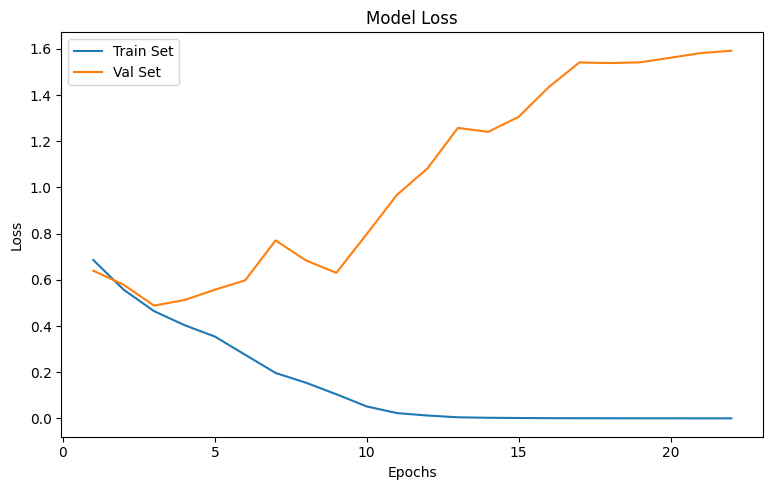

In [13]:
loss = history.history['loss']
val_loss = history.history['val_loss']
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs_range = range(1, len(history.epoch) + 1)

plt.figure(figsize=(15,5))

#plt.subplot(1, 2, 1)
#plt.plot(epochs_range, acc, label='Train Set')
#plt.plot(epochs_range, val_acc, label='Val Set')
#plt.legend(loc="best")
#plt.xlabel('Epochs')
#plt.ylabel('Accuracy')
#plt.title('Model Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Train Set')
plt.plot(epochs_range, val_loss, label='Val Set')
plt.legend(loc="best")
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Model Loss')

plt.tight_layout()
plt.show()

In [14]:
Y_probs = model.predict(X_test)

2/2 [==============================] - 0s 238ms/step


In [15]:
Y_pred = (Y_probs > 0.5).astype(int)

In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


accuracy = accuracy_score(Y_test, Y_pred)
precision = precision_score(Y_test, Y_pred)
recall = recall_score(Y_test, Y_pred)
f1 = f1_score(Y_test, Y_pred)
conf_matrix = confusion_matrix(Y_test, Y_pred)

print(f'Accuracy: {accuracy}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1-score: {f1}')
print(conf_matrix)

Accuracy: 0.9019607843137255
Precision: 0.90625
Recall: 0.9354838709677419
F1-score: 0.9206349206349206
[[17  3]
 [ 2 29]]


In [17]:
Y_pred = np.reshape(Y_pred, (Y_pred.shape[0],))
fp_indices = np.where((Y_pred == 1) & (Y_test == 0))[0]
fn_indices = np.where((Y_pred == 0) & (Y_test == 1))[0]

tn, fp, fn, tp = conf_matrix.ravel()
ttest = tn + fp+ fn + tp

X_fp = X_test[fp_indices]
Y_fp = Y_test[fp_indices]
X_fn = X_test[fn_indices]
Y_fn = Y_test[fn_indices]

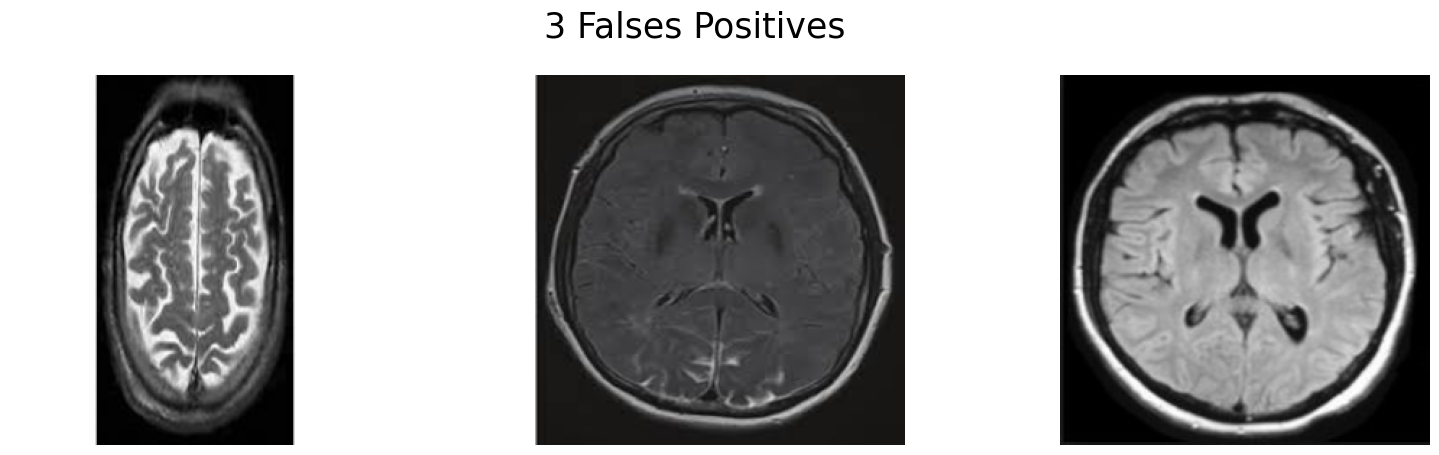

In [18]:

plt.figure(figsize=(20, 5))

for i in range(fp):
    plt.subplot(1, fp, i + 1)

    plt.imshow(X_test[fp_indices][i])
    plt.axis('off')

plt.suptitle(str(fp)+ " Falses Positives", color='black', fontsize=25)
plt.subplots_adjust(top=0.85,wspace=0.05, hspace=0.05)
plt.show()

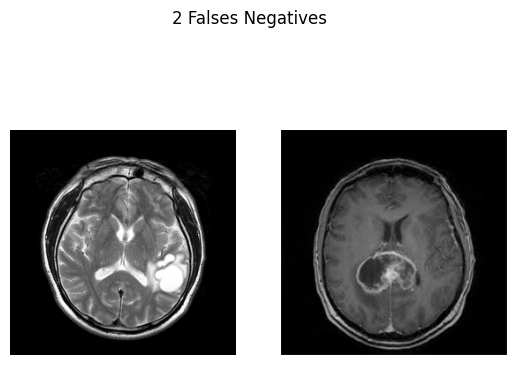

In [19]:
for i in range(fn):

    plt.subplot(1, fn, i + 1)
    plt.imshow(X_test[fn_indices][i])
    plt.axis('off')


plt.suptitle(str(fn)+ " Falses Negatives")
plt.show()

In [20]:
print(X_train.shape)
print(X_test.shape)

(202, 256, 256, 3)
(51, 256, 256, 3)


In [21]:
model_path = '/kaggle/working/my_model.h5'
model.save(model_path)

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [22]:
from sklearn.metrics import confusion_matrix

# Predict on training data
Y_train_pred = model.predict(X_train)
Y_train_pred = (Y_train_pred > 0.5).astype(int)

# Compute confusion matrix
conf_matrix_train = confusion_matrix(Y_train, Y_train_pred)
print("Confusion Matrix for Training Data:")
print(conf_matrix_train)


7/7 [==============================] - 0s 43ms/step
Confusion Matrix for Training Data:
[[ 77   1]
 [  2 122]]


In [23]:
# Predict on test data
Y_test_pred = model.predict(X_test)
Y_test_pred = (Y_test_pred > 0.5).astype(int)


2/2 [==============================] - 0s 11ms/step


In [24]:
# Compute confusion matrix for test data
conf_matrix_test = confusion_matrix(Y_test, Y_test_pred)
print("Confusion Matrix for Test Data:")
print(conf_matrix_test)


Confusion Matrix for Test Data:
[[17  3]
 [ 2 29]]


7/7 [==============================] - 0s 31ms/step


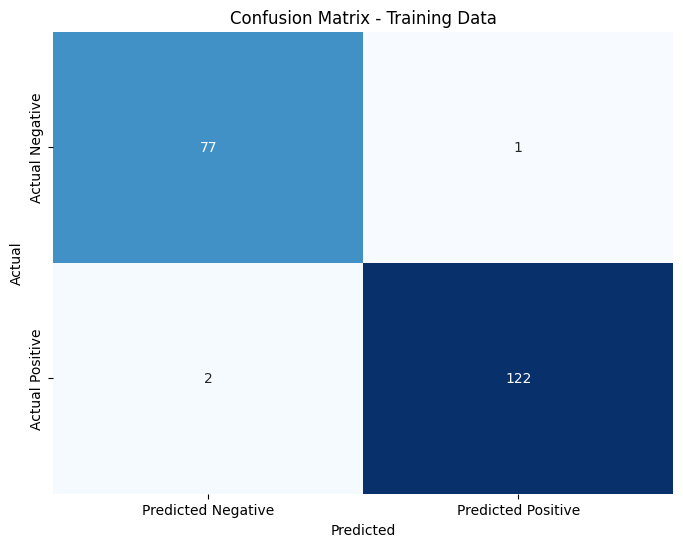

Classification Report - Training Data:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98        78
           1       0.99      0.98      0.99       124

    accuracy                           0.99       202
   macro avg       0.98      0.99      0.98       202
weighted avg       0.99      0.99      0.99       202



In [25]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Predict classes on training data
train_predictions = model.predict(X_train)
train_predicted_classes = (train_predictions > 0.5).astype(int)

# Compute confusion matrix
train_cm = confusion_matrix(Y_train, train_predicted_classes)

# Display confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(train_cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.title('Confusion Matrix - Training Data')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Print classification report
print("Classification Report - Training Data:")
print(classification_report(Y_train, train_predicted_classes))


2/2 [==============================] - 0s 13ms/step


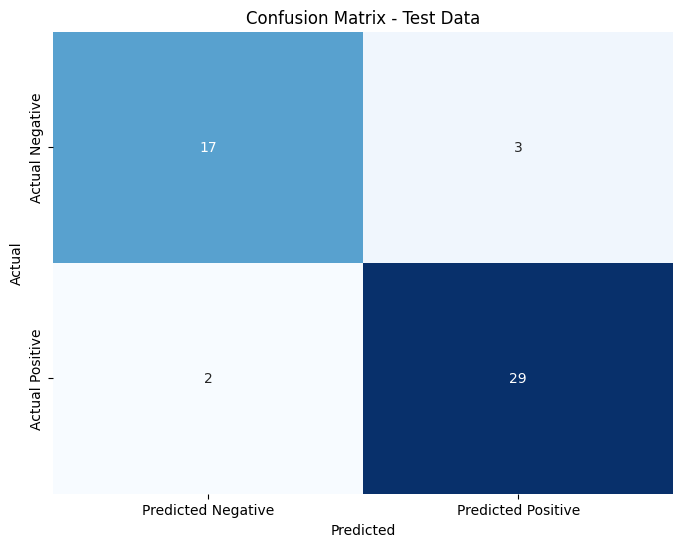

Classification Report - Test Data:
              precision    recall  f1-score   support

           0       0.89      0.85      0.87        20
           1       0.91      0.94      0.92        31

    accuracy                           0.90        51
   macro avg       0.90      0.89      0.90        51
weighted avg       0.90      0.90      0.90        51



In [26]:
# Predict classes on test data
test_predictions = model.predict(X_test)
test_predicted_classes = (test_predictions > 0.5).astype(int)

# Compute confusion matrix
test_cm = confusion_matrix(Y_test, test_predicted_classes)

# Display confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(test_cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.title('Confusion Matrix - Test Data')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Print classification report
print("Classification Report - Test Data:")
print(classification_report(Y_test, test_predicted_classes))
